# Chapter 7. Data Cleaning and Preparation

In [1]:
import numpy as np
import pandas as pd

## 7.5 Categorical Data

### Background and Motivation
- Many data systems have developed speciallized approaches for representing data with repeated values for more efficient storage and computation.
- In data warehousing, a best practice is **to use so-called dimension tables** containing the distinct values and storing the primary observations **as integer keys referecing the dimension table**:

In [3]:
values = pd.Series([0,1,0,0]*2)
dim = pd.Series(['apple','orange'])

> - We can use the ***take* method to restore the original Series of strings**:

In [4]:
dim.take(values)

0     apple
1    orange
0     apple
0     apple
0     apple
1    orange
0     apple
0     apple
dtype: object

- This representation as integer is called **the categorical or dictionary-encoded representation**.

> - The array of distinct values can be called the ***categories*, *dictionary*, or *levels*** of the data.
> - The **integer values** that reference the categories are called the ***category codes* or *simply codes***.

### Categorical Extension Type in pandas
- pandas has a special **Categorical** extension type for holding data that uses the **integer-based categorical representation or encoding**.
- Signicantly faster performance with lower memory use, especially for string data.
- **Categorical data need not be strings**. A categorical array can consist of any immutable value types.

In [6]:
fruits = ['apple','orange','apple','apple'] * 2
N = len(fruits)
rng = np.random.default_rng(seed=12345)

In [8]:
df = pd.DataFrame({'fruit':fruits, 'basket_id':np.arange(N),
                   'count':rng.integers(3,15,size=N),
                   'weight':rng.uniform(0,4,size=N)},
                  columns =['basket_id','fruit','count','weight'])
df

,basket_id,fruit,count,weight
0,0,apple,11,1.564438
1,1,orange,5,1.331256
2,2,apple,12,2.393235
3,3,apple,6,0.746937
4,4,apple,5,2.691024
5,5,orange,12,3.767211
6,6,apple,10,0.992983
7,7,apple,11,3.795525


> - Here, ***df['fruit']*** is an array of Python string objects. We can convert it to categorical by calling:

In [9]:
fruit_cat = df['fruit'].astype('category')
fruit_cat

0     apple
1    orange
2     apple
3     apple
4     apple
5    orange
6     apple
7     apple
Name: fruit, dtype: category
Categories (2, object): ['apple', 'orange']

> - The value for fruit_cat are now an instance of pandas.Categorical, which **you can access via the .array attribute**:

In [10]:
c = fruit_cat.array
type(c)

pandas.core.arrays.categorical.Categorical

In [11]:
c.categories

Index(['apple', 'orange'], dtype='object')

In [12]:
c.codes

array([0, 1, 0, 0, 0, 1, 0, 0], dtype=int8)

> - A useful trick **to get a mapping between codes and categories** is:

In [13]:
dict(enumerate(c.categories))

{0: 'apple', 1: 'orange'}

> - You can convert a DataFrame column to categorical by assigning the converted result:

In [18]:
df['fruit'] = df['fruit'].astype('category')
df['fruit']

0     apple
1    orange
2     apple
3     apple
4     apple
5    orange
6     apple
7     apple
Name: fruit, dtype: category
Categories (2, object): ['apple', 'orange']

> - You can also create ***pandas.Categorical*** directly **from other types of Python sequences**:

In [19]:
my_categories = pd.Categorical(['foo','bar','baz','foo','bar'])
my_categories

['foo', 'bar', 'baz', 'foo', 'bar']
Categories (3, object): ['bar', 'baz', 'foo']

> - If you have obtained categorical encoded data from another source, you can use the alternative ***from_codes*** constructor:
> - When using *from_codes* or any of the other constructors, you can **indicate that the categories have a meaningful ordering**:
> - An unordered categorical instance can be more ordered with ***as_ordered***:

In [2]:
categories = ['foo','bar','baz']
codes = [0,1,2,0,0,1]

In [3]:
my_cat_2 = pd.Categorical.from_codes(codes, categories)
my_cat_2

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo', 'bar', 'baz']

In [4]:
my_cat_2.as_ordered()

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo' < 'bar' < 'baz']

In [5]:
ordered_cat = pd.Categorical.from_codes(codes, categories, 
                                         ordered=True)
ordered_cat

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo' < 'bar' < 'baz']

### Computations with Categoricals
- Some parts of pandas, like the ***groupby*** function, **perform better** when working with categoricals.
- Because the underlying algorithms **use the integer_based codes array instead of an array of strings**.

In [6]:
rng = np.random.default_rng(seed=12345)
draws = rng.standard_normal(1000)
draws[:5]

array([-1.42382504,  1.26372846, -0.87066174, -0.25917323, -0.07534331])

In [7]:
bins = pd.qcut(draws, 4)
bins

[(-3.121, -0.675], (0.687, 3.211], (-3.121, -0.675], (-0.675, 0.0134], (-0.675, 0.0134], ..., (0.0134, 0.687], (0.0134, 0.687], (-0.675, 0.0134], (0.0134, 0.687], (-0.675, 0.0134]]
Length: 1000
Categories (4, interval[float64, right]): [(-3.121, -0.675] < (-0.675, 0.0134] < (0.0134, 0.687] < (0.687, 3.211]]

In [8]:
bins = pd.qcut(draws, 4, labels=['Q1','Q2','Q3','Q4'])
bins

['Q1', 'Q4', 'Q1', 'Q2', 'Q2', ..., 'Q3', 'Q3', 'Q2', 'Q3', 'Q2']
Length: 1000
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']

> - We can use *groupby* **to extract some summary statistics**: 

In [9]:
bins = pd.Series(bins, name='quartile')
bins

0      Q1
1      Q4
2      Q1
3      Q2
4      Q2
       ..
995    Q3
996    Q3
997    Q2
998    Q3
999    Q2
Name: quartile, Length: 1000, dtype: category
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']

In [11]:
result = (pd.Series(draws).groupby(bins)
 .agg(['count','min','max']).reset_index())
# 하나씩 추가하면서 결과 확인해 볼 것
# 오른쪽의 괄호는 행바꿈 적용하기 위해 사용한 것임
result

,quartile,count,min,max
0,Q1,250,-3.119609,-0.678494
1,Q2,250,-0.673305,0.008009
2,Q3,250,0.018753,0.686183
3,Q4,250,0.688282,3.211418


### Categorical Methods

In [19]:
s = pd.Series(['a','b','c','d']*2)
cat_s = s.astype('category')
cat_s

0    a
1    b
2    c
3    d
4    a
5    b
6    c
7    d
dtype: category
Categories (4, object): ['a', 'b', 'c', 'd']

In [29]:
b = cat_s.array
type(b) # pandas.core.array.categorical.Categorical
b.codes # ndarray 데이터 형식
b.categories # Index 형식

Index(['a', 'b', 'c', 'd'], dtype='object')

In [30]:
c = cat_s.cat
type(c) # pandas.core.arrays.categorical.CategoricalAccessor
c.codes # Series 데이터 형식
c.categories # Index 형식

Index(['a', 'b', 'c', 'd'], dtype='object')

> - We can use the ***set_categories*** method **to chage the category index**:

In [32]:
actual_categories = ['a','b','c','d','e']
cat_s2 = cat_s.cat.set_categories(actual_categories)
cat_s2

0    a
1    b
2    c
3    d
4    a
5    b
6    c
7    d
dtype: category
Categories (5, object): ['a', 'b', 'c', 'd', 'e']

In [33]:
cat_s.value_counts()

a    2
b    2
c    2
d    2
dtype: int64

In [34]:
cat_s2.value_counts()

a    2
b    2
c    2
d    2
e    0
dtype: int64

> - ***remove_unused_categories*** : To trim unobserved categories: 

In [36]:
cat_s3 = cat_s[cat_s.isin(['a','b'])]
cat_s3

0    a
1    b
4    a
5    b
dtype: category
Categories (4, object): ['a', 'b', 'c', 'd']

In [37]:
cat_s3.cat.remove_unused_categories()

0    a
1    b
4    a
5    b
dtype: category
Categories (2, object): ['a', 'b']

> Categorical methods for Series in pandas
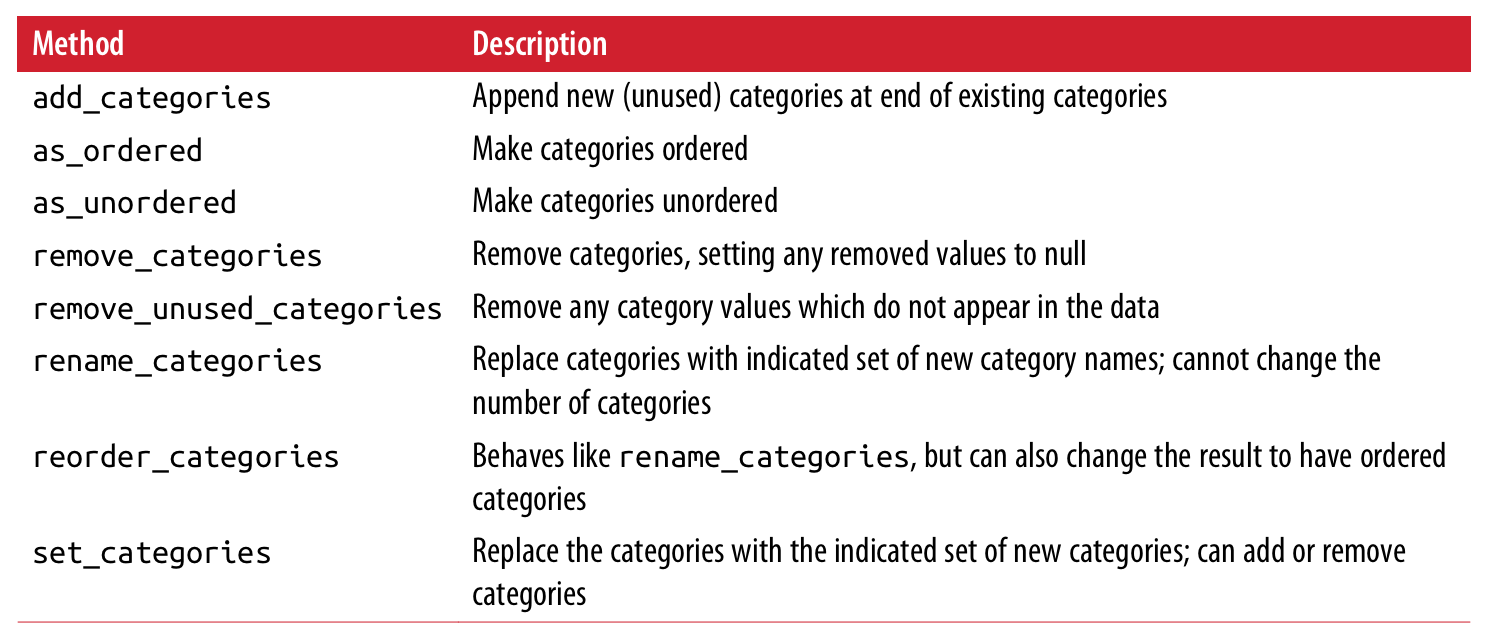

> - When you are using statistics or machine learning tools, you'll often **transform categorical data into *dummy variables***, also known as ***one-hot encoding***.
> - ***pandas.get_dummies*** : Converting one-dimensional categorical data into a DataFrame containing the dummy variable:

In [38]:
cat_s = pd.Series(['a','b','c','d']*2, dtype='category')
pd.get_dummies(cat_s)

,a,b,c,d
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1
4,1,0,0,0
5,0,1,0,0
6,0,0,1,0
7,0,0,0,1
